#  Mental Health Risk Intelligence System
## Data Exploration and Preprocessing 
This notebook performs exploratory data analysis, preprocessing validation, feature extraction validation, and testing of the NLP pipeline.

## 1. Import Libraries
Load required libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset
Load the mental health dataset and preview records.

In [2]:
df=pd.read_csv("../data/raw/mental_health.csv")
df.head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


## 3. Dataset Information
Inspect shape, columns, and missing values.

In [3]:
print("Shape:",df.shape)
print("\nColumns:\n",df.columns)
print("\nMissing Values:\n",df.isnull().sum())

Shape: (992, 2)

Columns:
 Index(['text', 'status'], dtype='str')

Missing Values:
 text      0
status    0
dtype: int64


## 4. Class Distribution Analysis
Analyze class balance in the target labels.

In [4]:
df["status"].value_counts()

status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64

## 5. Visualize Class Distribution

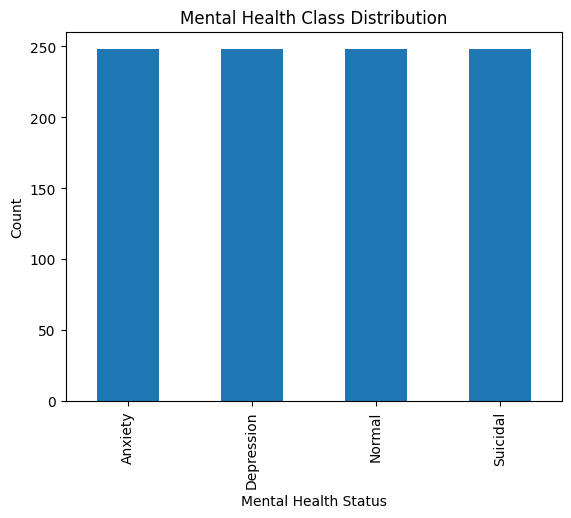

In [5]:
df["status"].value_counts().plot(kind="bar")
plt.title("Mental Health Class Distribution")
plt.xlabel("Mental Health Status")
plt.ylabel("Count")
plt.show()

## 6. Text Preprocessing Setup
Import and load cleaning pipeline.

In [6]:
import sys,os,importlib
project_root=os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)
import preprocessing.clean_text
importlib.reload(preprocessing.clean_text)
from preprocessing.clean_text import clean_text

## 7. Apply Text Cleaning
Perform lowercasing, stopword removal, lemmatization and filtering.

In [7]:
df["clean_text"]=df["text"].apply(clean_text)
df[["text","clean_text"]].head(10)

,text,clean_text
0,i don't understand whats wrong with me. i don'...,understand wrong freak lay bed happen keep tea...
1,usually when i have anxiety just chatting with...,anxiety chat need start feel well anxiety bad ...
2,"well, i've had anxiety and panic syndrome for ...",anxiety panic syndrome year start school heart...
3,"for the most minimal of things, like standing ...",minimal stand someone way moment notice charac...
4,i stay away from family and live with my roomm...,stay family live roommate game fuckin time hap...
5,"i'm very ecstatic, i got a job that literally ...",ecstatic get job fit anxiety family member min...
6,"i've been feeling anxious today, but it's alwa...",feel anxious good reminder fear anxious feelin...
7,i quit my job today. it was fucking terrible. ...,quit job fuck terrible quit bad time work try ...
8,after months of being stuck in a loop of stayi...,month stick loop stay indoor step comfort zone...
9,i’m at a resort with my friends and their pare...,resort friend parent friend bar crowd disco ar...


## 8. Data Integrity Check
Verify null and empty values after preprocessing.

In [8]:
print(df["clean_text"].isnull().sum())
print((df["clean_text"]=="").sum())

0
0


## 9. Word Cloud Visualization
Visualize frequent words in cleaned text.

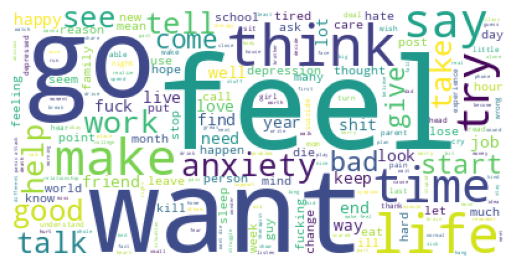

In [9]:
from wordcloud import WordCloud
text=" ".join(df["clean_text"])
wordcloud=WordCloud(background_color="white").generate(text)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## 10. TF-IDF Feature Extraction

In [10]:
from feature_engineering.tfidf_features import TfidfFeatureExtractor
extractor=TfidfFeatureExtractor()
X=extractor.fit_transform(df["clean_text"])
print(X.shape)

(992, 15000)


## 11. Emotion Detection Test

In [11]:
from feature_engineering.emotion_features import detect_emotions
sample="I feel hopeless and lonely"
detect_emotions(sample)

2026-05-19 19:03:50.486 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

{'sadness': 0.989,
 'neutral': 0.005,
 'fear': 0.002,
 'disgust': 0.002,
 'surprise': 0.001,
 'joy': 0.001,
 'anger': 0.001}

## 12. Critical Phrase Detection Test

In [12]:
from feature_engineering.critical_detector import detect_critical
sample="I want to disappear. No reason to live"
detect_critical(sample)

['want to disappear', 'no reason to live']

## 13. Sentiment Analysis Test

In [13]:
from feature_engineering.sentiment_features import get_sentiment
sample="I feel stressed and exhausted"
get_sentiment(sample)

2026-05-19 19:04:10.789 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{'label': 'NEGATIVE', 'score': 1.0}

## 14. Risk Engine Testing

In [14]:
from models.risk_engine import calculate_risk
sample="I want to disappear. No reason to live."
calculate_risk(sample)

{'risk_score': 98,
 'risk_level': 'HIGH',
 'sentiment': {'label': 'NEGATIVE', 'score': 1.0},
 'emotions': {'sadness': 0.912,
  'anger': 0.05,
  'fear': 0.015,
  'neutral': 0.011,
  'disgust': 0.009,
  'surprise': 0.002,
  'joy': 0.002},
 'critical_matches': ['want to disappear', 'no reason to live']}

## 15. Save Cleaned Dataset

In [15]:
df.to_csv("../data/processed/cleaned_data.csv",index=False)
print("Saved successfully")

Saved successfully


## Conclusion
The dataset was explored, validated, cleaned, transformed and tested for downstream machine learning tasks.